# Hyperparameter Tuning with Optuna

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import optuna
from optuna.trial import TrialState

import fasttext
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

import warnings
warnings.filterwarnings('ignore')

# Fixed config
RANDOM_SEED = 42
MAX_LENGTH = 256
N_TRIALS = 50
N_FOLDS = 3

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


Device: cuda


In [2]:
# Load data
DATA_DIR = Path('/kaggle/input/steam-review')
MODEL_DIR = Path('/kaggle/input/fasttext-steam-200/other/default/1')

train_df = pd.read_csv(DATA_DIR / 'train.csv')
X_train = train_df['processed_text'].fillna('').values
y_train = train_df['voted_up'].astype(int).values
stratify_key = train_df['voted_up'].astype(str) + '_' + train_df['primary_genre'].astype(str)

# Load FastText
ft_model = fasttext.load_model(str(MODEL_DIR / 'steam_fasttext.bin'))
EMBEDDING_DIM = ft_model.get_dimension()
print(f"Loaded: {len(train_df)} samples, {EMBEDDING_DIM}-dim embeddings")

Loaded: 34481 samples, 200-dim embeddings


In [3]:
class SteamReviewDataset(Dataset):
    def __init__(self, texts, labels, ft_model, max_length=256):
        self.texts = texts
        self.labels = labels
        self.ft_model = ft_model
        self.max_length = max_length
        self.embedding_dim = ft_model.get_dimension()
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = text.split()[:self.max_length]
        embeddings = np.zeros((self.max_length, self.embedding_dim), dtype=np.float32)
        for i, token in enumerate(tokens):
            embeddings[i] = self.ft_model.get_word_vector(token)
        mask = np.zeros(self.max_length, dtype=np.float32)
        mask[:len(tokens)] = 1.0
        return {
            'embeddings': torch.tensor(embeddings, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32)
        }


class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False)
        )
    
    def forward(self, gru_output, mask):
        scores = self.attention(gru_output).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e4)
        attention_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attention_weights.unsqueeze(1), gru_output).squeeze(1)
        return context


class SentimentClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.attention = Attention(hidden_dim * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, embeddings, mask):
        self.gru.flatten_parameters()
        gru_output, _ = self.gru(embeddings)
        context = self.attention(gru_output, mask)
        return self.classifier(context)

In [4]:
def train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, scaler, device, n_epochs=10):
    """Train model and return best validation F1."""
    best_f1 = 0
    patience, patience_counter = 3, 0
    
    for epoch in range(n_epochs):
        # Train
        model.train()
        for batch in train_loader:
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            with autocast(device_type=device.type):
                logits = model(embeddings, mask).squeeze(-1)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        
        # Validate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                embeddings = batch['embeddings'].to(device)
                mask = batch['mask'].to(device)
                labels = batch['label'].to(device)
                with autocast(device_type=device.type):
                    logits = model(embeddings, mask).squeeze(-1)
                preds = (torch.sigmoid(logits) > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_f1 = f1_score(all_labels, all_preds)
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    return best_f1

In [5]:
def objective(trial):
    """Optuna objective function."""
    
    # Hyperparameters to tune
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    # Cross-validation
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, stratify_key)):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        train_dataset = SteamReviewDataset(X_fold_train, y_fold_train, ft_model, MAX_LENGTH)
        val_dataset = SteamReviewDataset(X_fold_val, y_fold_val, ft_model, MAX_LENGTH)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
        
        model = SentimentClassifier(EMBEDDING_DIM, hidden_dim, num_layers, dropout).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        criterion = nn.BCEWithLogitsLoss()
        scaler = GradScaler()
        
        fold_f1 = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, scaler, device)
        fold_scores.append(fold_f1)
        
        # Pruning: if this fold is worse than median, prune early
        trial.report(np.mean(fold_scores), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(fold_scores)

In [6]:
# Create and run study
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("BEST HYPERPARAMETERS")
print(f"Best F1 Score: {study.best_value:.4f}")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-12-27 15:41:51,410] A new study created in memory with name: no-name-b5a1e95c-b526-4411-a1b8-59ef5f73d29d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-27 15:54:40,898] Trial 0 finished with value: 0.882465135332105 and parameters: {'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.37256623359366725, 'learning_rate': 0.0003157124351049379, 'weight_decay': 0.0021479337290275335, 'batch_size': 32}. Best is trial 0 with value: 0.882465135332105.
[I 2025-12-27 16:24:49,559] Trial 1 finished with value: 0.6667053311936648 and parameters: {'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.38097478113317873, 'learning_rate': 0.008838462721675546, 'weight_decay': 2.727868218686034e-05, 'batch_size': 16}. Best is trial 0 with value: 0.882465135332105.
[I 2025-12-27 16:46:34,291] Trial 2 finished with value: 0.8802345143794287 and parameters: {'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.24400534218666234, 'learning_rate': 0.00025520661798170727, 'weight_decay': 0.00035864614031167093, 'batch_size': 16}. Best is trial 0 with value: 0.882465135332105.
[I 2025-12-27 16:56:42,141] Trial 3 finished with value: 0.8861155690274173 and pa

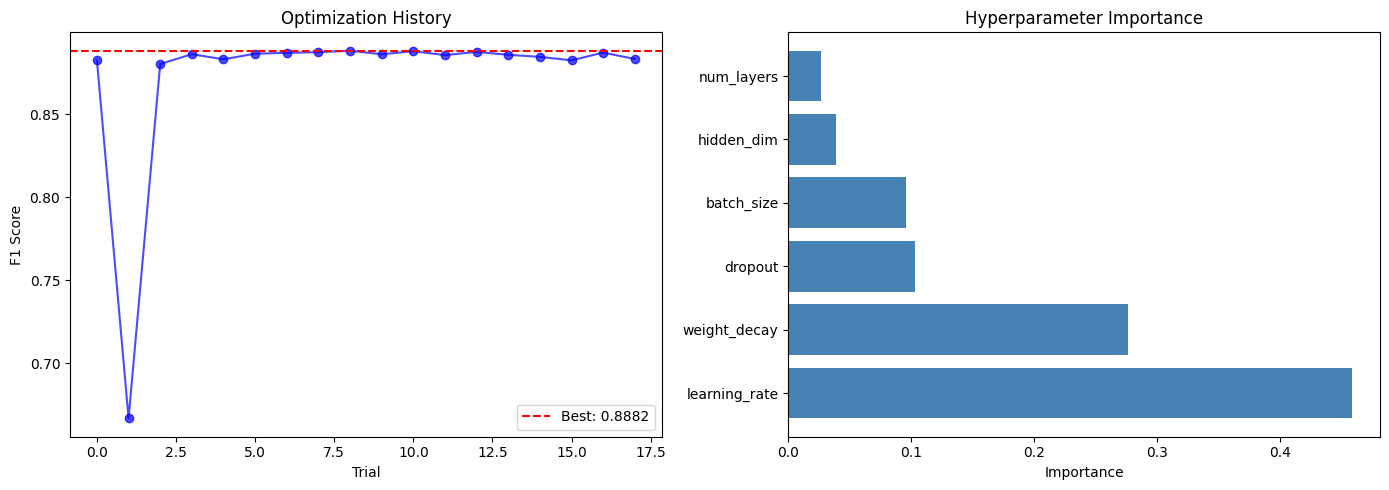

In [7]:
# Visualize optimization
import matplotlib.pyplot as plt
from optuna.importance import MeanDecreaseImpurityImportanceEvaluator

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trials = [t for t in study.trials if t.state == TrialState.COMPLETE]
values = [t.value for t in trials]
axes[0].plot(values, 'bo-', alpha=0.7)
axes[0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Optimization History')
axes[0].legend()

# Hyperparameter importance (using MDI evaluator to avoid fANOVA issues)
try:
    importance = optuna.importance.get_param_importances(
        study, 
        evaluator=MeanDecreaseImpurityImportanceEvaluator()
    )
    params = list(importance.keys())
    importances = list(importance.values())
    axes[1].barh(params, importances, color='steelblue')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance')
except Exception as e:
    print(f'Could not compute param importances: {e}')
    axes[1].text(0.5, 0.5, 'Importance unavailable', ha='center', va='center')
    axes[1].set_title('Hyperparameter Importance (Error)')

plt.tight_layout()
plt.show()

In [8]:
# Save best params
import json

best_config = {
    'best_f1': study.best_value,
    'best_params': study.best_params
}

with open('optuna_best_params.json', 'w') as f:
    json.dump(best_config, f, indent=2)

print("Best config saved to optuna_best_params.json")

Best config saved to optuna_best_params.json
